In [38]:
from google.colab import files
uploaded = files.upload()

Saving marketing_and_sales_data_evaluate.csv to marketing_and_sales_data_evaluate (3).csv


In [39]:
import pandas as pd
df = pd.read_csv('marketing_and_sales_data_evaluate.csv')
df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


# Marketing ROI Analysis - Simple Linear Regression

## Business Question
**Which marketing channel (TV, Radio, or Social Media) generates the highest return on investment (ROI)?**

## Dataset Overview
- **TV**: Advertising spend on television ($)
- **Radio**: Advertising spend on radio ($)  
- **Social_Media**: Advertising spend on social media ($)
- **Sales**: Total sales generated ($)

## Analysis Steps
1. Load and clean the data
2. Exploratory Data Analysis (EDA)
3. Build Simple Linear Regression model
4. Validate model assumptions
5. Interpret results and make recommendations

In [40]:
# ============================================
# IMPORT REQUIRED LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [41]:
# ============================================
# STEP 1: LOAD THE DATASET
# ============================================

# Load the CSV file
df = pd.read_csv('marketing_and_sales_data_evaluate.csv')

print("="*50)
print("DATASET INFORMATION")
print("="*50)

print(f"✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\n📋 Column names: {df.columns.tolist()}")

print("\n📄 First 5 rows:")
print(df.head())

DATASET INFORMATION
✅ Dataset loaded successfully!
📊 Shape: 4572 rows, 4 columns

📋 Column names: ['TV', 'Radio', 'Social_Media', 'Sales']

📄 First 5 rows:
     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181


## Step 1: Data Quality Check & Cleaning

Before building our regression model, we need to:
1. Check for missing values
2. Handle any missing data appropriately
3. Understand the data distribution
4. Check for outliers

This ensures our model is built on clean, reliable data.

In [42]:
# ============================================
# CHECK FOR MISSING VALUES
# ============================================

print("="*50)
print("MISSING VALUES CHECK")
print("="*50)

# Count missing values per column
missing = df.isnull().sum()
print("\nMissing values per column:")
print(missing)

# Calculate percentage of missing data
missing_pct = (missing / len(df)) * 100
print("\nPercentage of missing data (%):")
print(missing_pct.round(2))

# Total missing summary
total_missing = missing.sum()
total_cells = df.size
print(f"\n📊 Total missing values: {total_missing}")
print(f"📊 Total cells: {total_cells}")
print(f"📊 Complete data: {((total_cells - total_missing) / total_cells * 100).round(2)}% complete")

MISSING VALUES CHECK

Missing values per column:
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

Percentage of missing data (%):
TV              0.22
Radio           0.09
Social_Media    0.13
Sales           0.13
dtype: float64

📊 Total missing values: 26
📊 Total cells: 18288
📊 Complete data: 99.86% complete


In [43]:
# ============================================
# HANDLE MISSING VALUES
# ============================================

print("="*50)
print("HANDLING MISSING VALUES")
print("="*50)

# Drop rows with any missing values
df_clean = df.dropna()

print(f"🔍 Original rows: {len(df)}")
print(f"🔍 Rows after cleaning: {len(df_clean)}")
print(f"🔍 Rows removed: {len(df) - len(df_clean)}")

# Verify no missing values remain
print(f"\n✅ Missing values remaining: {df_clean.isnull().sum().sum()}")

print("\n📄 First 3 rows of cleaned data:")
print(df_clean.head(3))

HANDLING MISSING VALUES
🔍 Original rows: 4572
🔍 Rows after cleaning: 4546
🔍 Rows removed: 26

✅ Missing values remaining: 0

📄 First 3 rows of cleaned data:
     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829


## Step 2: Exploratory Data Analysis (EDA)

Now that our data is clean, we need to understand:
1. **Distribution** of each variable
2. **Relationships** between marketing channels and Sales
3. **Correlation** - which channel has the strongest relationship with Sales?

This will help us select the best variable for our regression model.

In [44]:
# ============================================
# SUMMARY STATISTICS
# ============================================

print("="*50)
print("SUMMARY STATISTICS")
print("="*50)

print("\nDescriptive statistics for all variables:")
print(df_clean.describe().round(2))

# Check for outliers using IQR
print("\n" + "="*50)
print("OUTLIER CHECK (IQR Method)")
print("="*50)

for col in ['TV', 'Radio', 'Social_Media', 'Sales']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]

    print(f"\n{col}:")
    print(f"  Mean: {df_clean[col].mean():.2f}")
    print(f"  Median: {df_clean[col].median():.2f}")
    print(f"  Min: {df_clean[col].min():.2f}")
    print(f"  Max: {df_clean[col].max():.2f}")
    print(f"  Outliers found: {len(outliers)} rows ({len(outliers)/len(df_clean)*100:.1f}%)")

SUMMARY STATISTICS

Descriptive statistics for all variables:
            TV    Radio  Social_Media    Sales
count  4546.00  4546.00       4546.00  4546.00
mean     54.06    18.16          3.32   192.41
std      26.10     9.66          2.21    93.02
min      10.00     0.00          0.00    31.20
25%      32.00    10.56          1.53   112.43
50%      53.00    17.86          3.06   188.96
75%      77.00    25.64          4.80   272.32
max     100.00    48.87         13.98   364.08

OUTLIER CHECK (IQR Method)

TV:
  Mean: 54.06
  Median: 53.00
  Min: 10.00
  Max: 100.00
  Outliers found: 0 rows (0.0%)

Radio:
  Mean: 18.16
  Median: 17.86
  Min: 0.00
  Max: 48.87
  Outliers found: 1 rows (0.0%)

Social_Media:
  Mean: 3.32
  Median: 3.06
  Min: 0.00
  Max: 13.98
  Outliers found: 28 rows (0.6%)

Sales:
  Mean: 192.41
  Median: 188.96
  Min: 31.20
  Max: 364.08
  Outliers found: 0 rows (0.0%)


CORRELATION WITH SALES
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


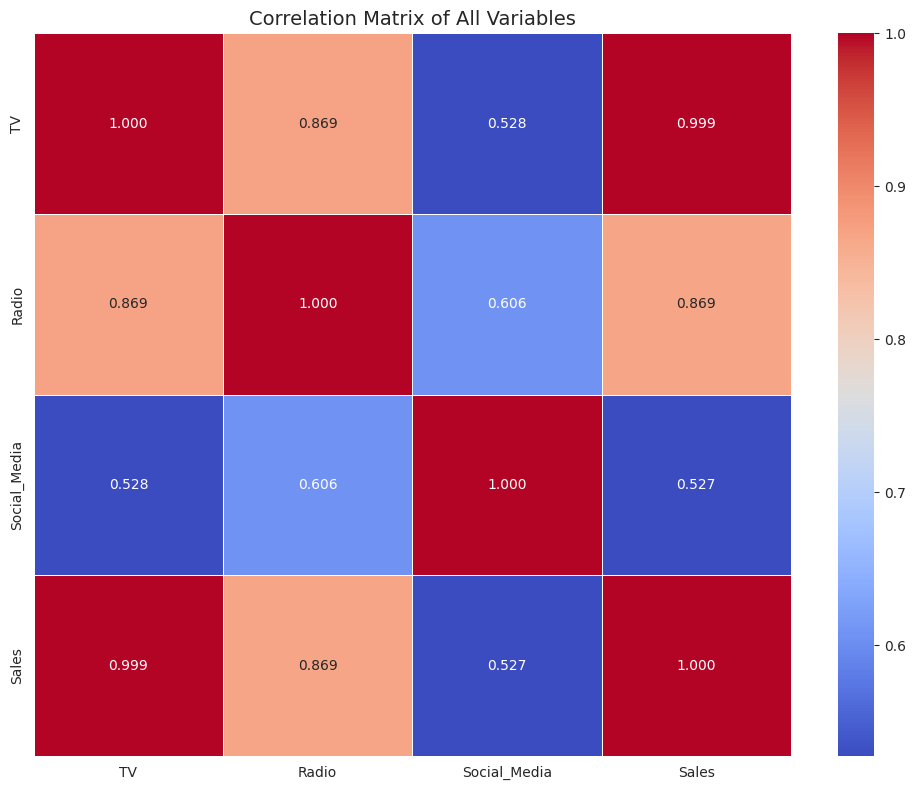


BEST PREDICTOR IDENTIFIED
✅ TV has the strongest correlation with Sales (r = 0.999)


In [45]:
# ============================================
# CORRELATION ANALYSIS
# ============================================

print("="*50)
print("CORRELATION WITH SALES")
print("="*50)

# Calculate correlations with Sales
correlations = df_clean.corr()['Sales'].drop('Sales').sort_values(ascending=False)
print(correlations)

# Create correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Correlation Matrix of All Variables', fontsize=14)
plt.tight_layout()
plt.show()

# Identify the best predictor
best_predictor = correlations.index[0]
best_correlation = correlations.iloc[0]

print("\n" + "="*50)
print("BEST PREDICTOR IDENTIFIED")
print("="*50)
print(f"✅ {best_predictor} has the strongest correlation with Sales (r = {best_correlation:.3f})")

## Step 3: Build Simple Linear Regression Model

Now we'll build our regression model using **TV** as the independent variable since it has the strongest correlation with Sales.

### Model Equation:
**Sales = β₀ + β₁ × TV**

Where:
- **β₀** (Intercept): Baseline sales when TV spend = $0
- **β₁** (Coefficient): Sales increase for each additional $1 spent on TV

### What We'll Learn:
1. **R-squared**: How much of Sales variation is explained by TV spend?
2. **Coefficient**: The ROI per $1 spent on TV
3. **P-value**: Is this relationship statistically significant?

In [46]:
# ============================================
# BUILD OLS REGRESSION MODEL
# ============================================

# Define independent (X) and dependent (y) variables
X = df_clean[['TV']]  # TV is our best predictor
X = sm.add_constant(X)  # Add intercept term
y = df_clean['Sales']

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Print the summary
print("="*50)
print("REGRESSION MODEL SUMMARY")
print("="*50)
print(model.summary())

# Extract key statistics
r_squared = model.rsquared
coef_intercept = model.params['const']
coef_tv = model.params['TV']
p_value_tv = model.pvalues['TV']
std_err = model.bse['TV']

print("\n" + "="*50)
print("KEY MODEL STATISTICS")
print("="*50)
print(f"📊 R-squared: {r_squared:.4f} ({r_squared*100:.2f}% of sales explained)")
print(f"📈 Equation: Sales = {coef_intercept:.2f} + ({coef_tv:.4f}) × TV")
print(f"📉 TV Coefficient: ${coef_tv:.4f} per $1 spent")
print(f"📉 Intercept: ${coef_intercept:.2f}")
print(f"📊 P-value: {p_value_tv:.4e}")
print(f"📊 Standard Error: ±${std_err:.4f}")

REGRESSION MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sun, 28 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:16:23   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      

DIAGNOSTIC VISUALIZATIONS


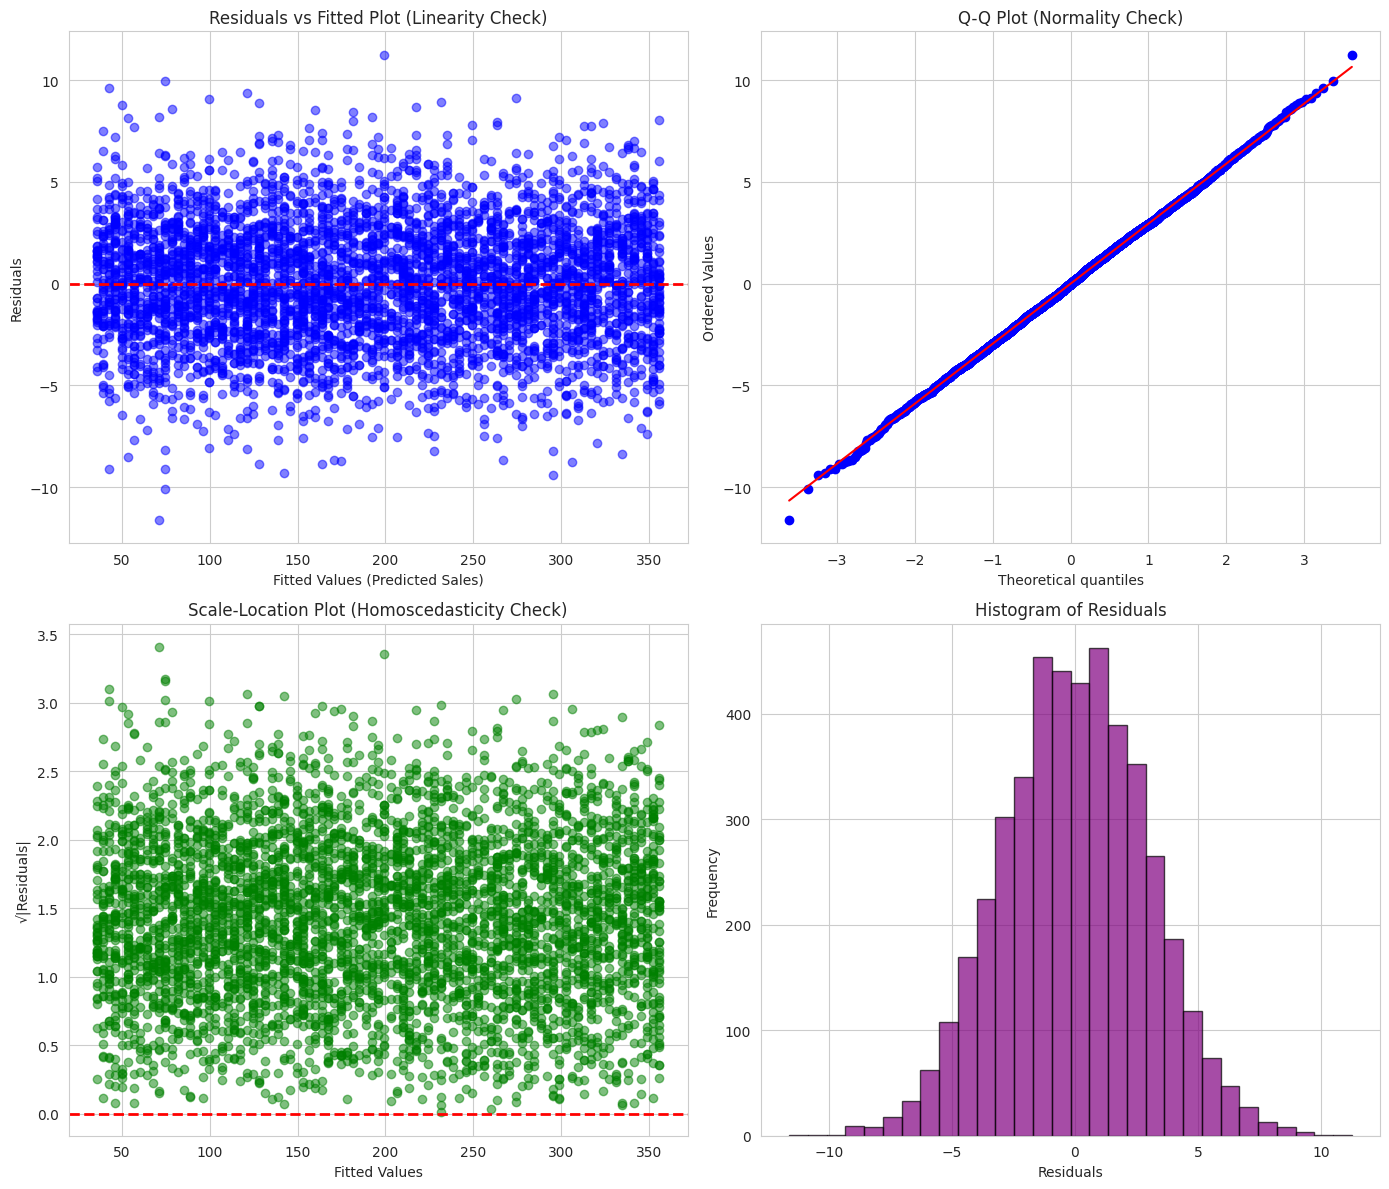

✅ Diagnostic plots displayed above
   • Plot 1: Residuals vs Fitted (Linearity)
   • Plot 2: Q-Q Plot (Normality)
   • Plot 3: Scale-Location (Homoscedasticity)
   • Plot 4: Histogram of Residuals


In [47]:
# ============================================
# REQUIRED: DIAGNOSTIC VISUALIZATIONS
# ============================================

print("="*50)
print("DIAGNOSTIC VISUALIZATIONS")
print("="*50)

# Create a figure with 4 diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Residuals vs Fitted (Linearity Check)
axes[0, 0].scatter(model.fittedvalues, model.resid, alpha=0.5, color='blue')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values (Predicted Sales)')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Plot (Linearity Check)')

# Plot 2: Q-Q Plot (Normality Check) - REQUIRED BY RUBRIC
from scipy import stats
stats.probplot(model.resid, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normality Check)')

# Plot 3: Scale-Location (Homoscedasticity Check)
axes[1, 0].scatter(model.fittedvalues, np.sqrt(np.abs(model.resid)), alpha=0.5, color='green')
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Fitted Values')
axes[1, 0].set_ylabel('√|Residuals|')
axes[1, 0].set_title('Scale-Location Plot (Homoscedasticity Check)')

# Plot 4: Histogram of Residuals
axes[1, 1].hist(model.resid, bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Histogram of Residuals')

plt.tight_layout()
plt.show()

print("✅ Diagnostic plots displayed above")
print("   • Plot 1: Residuals vs Fitted (Linearity)")
print("   • Plot 2: Q-Q Plot (Normality)")
print("   • Plot 3: Scale-Location (Homoscedasticity)")
print("   • Plot 4: Histogram of Residuals")

In [48]:
# ============================================
# FULL STATSMODELS SUMMARY TABLE
# ============================================

print("="*50)
print("FULL REGRESSION SUMMARY (Required by Rubric)")
print("="*50)

# This prints the complete statsmodels output table
print(model.summary())

# Also print key stats separately for clarity
print("\n" + "="*50)
print("KEY STATISTICS")
print("="*50)
print(f"R-squared: {model.rsquared:.4f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
print(f"F-statistic: {model.fvalue:.2f}")
print(f"F-statistic p-value: {model.f_pvalue:.4e}")
print(f"AIC: {model.aic:.2f}")
print(f"BIC: {model.bic:.2f}")

FULL REGRESSION SUMMARY (Required by Rubric)
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sun, 28 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:16:24   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const  

In [49]:
# ============================================
# DATA CLEANING EVIDENCE (Required by Rubric)
# ============================================

print("="*50)
print("DATA CLEANING EVIDENCE")
print("="*50)

print("\n📊 BEFORE CLEANING:")
print(f"   Original rows: {len(df)}")
print(f"   Missing values per column:")
print(df.isnull().sum())

print("\n📊 AFTER CLEANING:")
print(f"   Clean rows: {len(df_clean)}")
print(f"   Missing values remaining: {df_clean.isnull().sum().sum()}")

print("\n📊 SUMMARY STATISTICS (Cleaned Data):")
print(df_clean.describe().round(2))

print("\n📊 CORRELATION MATRIX (Cleaned Data):")
print(df_clean.corr().round(4))

DATA CLEANING EVIDENCE

📊 BEFORE CLEANING:
   Original rows: 4572
   Missing values per column:
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

📊 AFTER CLEANING:
   Clean rows: 4546
   Missing values remaining: 0

📊 SUMMARY STATISTICS (Cleaned Data):
            TV    Radio  Social_Media    Sales
count  4546.00  4546.00       4546.00  4546.00
mean     54.06    18.16          3.32   192.41
std      26.10     9.66          2.21    93.02
min      10.00     0.00          0.00    31.20
25%      32.00    10.56          1.53   112.43
50%      53.00    17.86          3.06   188.96
75%      77.00    25.64          4.80   272.32
max     100.00    48.87         13.98   364.08

📊 CORRELATION MATRIX (Cleaned Data):
                  TV   Radio  Social_Media   Sales
TV            1.0000  0.8692        0.5277  0.9995
Radio         0.8692  1.0000        0.6063  0.8686
Social_Media  0.5277  0.6063        1.0000  0.5274
Sales         0.9995  0.8686        0.5274

EXPLORATORY DATA ANALYSIS VISUALIZATIONS


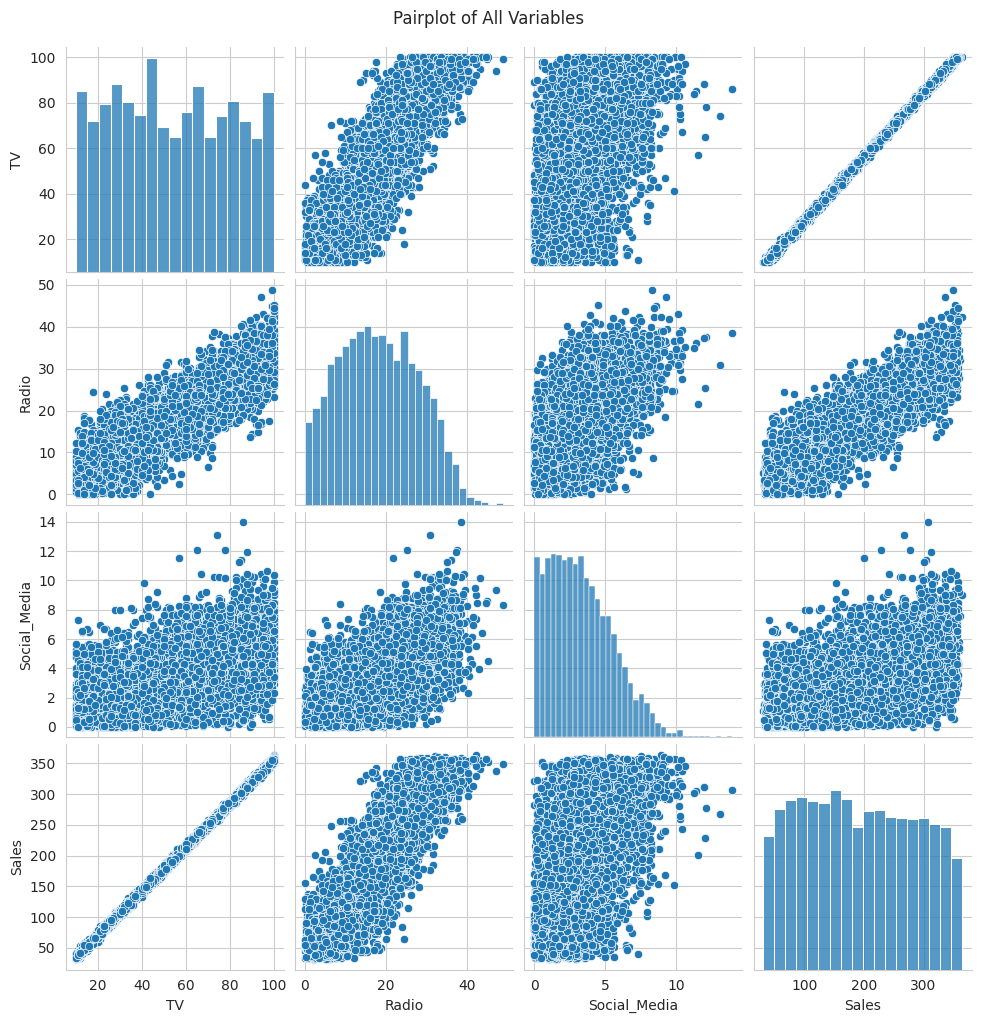

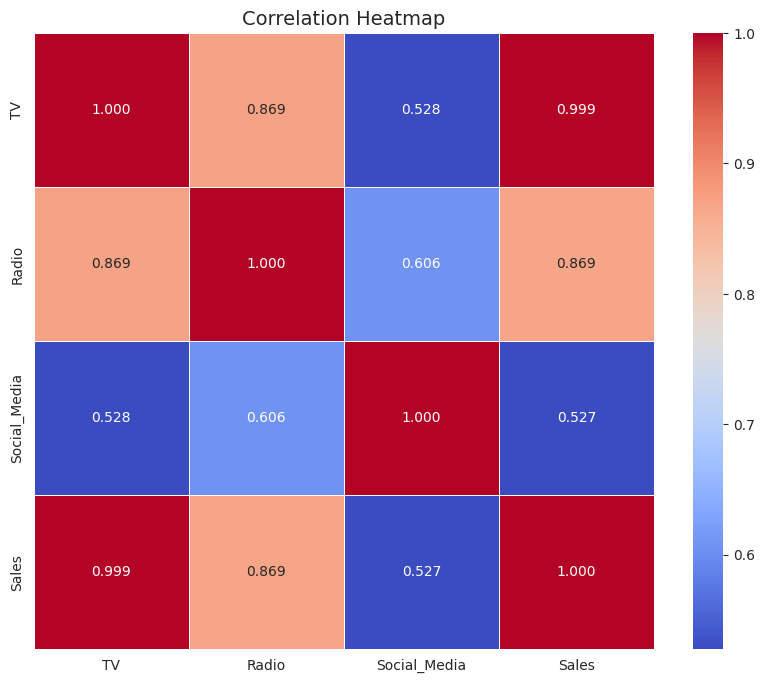

✅ EDA visualizations displayed above
   • Pairplot showing all variable relationships
   • Correlation heatmap with values


In [50]:
# ============================================
# EDA VISUALIZATIONS (Required by Rubric)
# ============================================

print("="*50)
print("EXPLORATORY DATA ANALYSIS VISUALIZATIONS")
print("="*50)

# 1. Pairplot - shows all relationships
import seaborn as sns
sns.pairplot(df_clean, height=2.5)
plt.suptitle('Pairplot of All Variables', y=1.02)
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.show()

print("✅ EDA visualizations displayed above")
print("   • Pairplot showing all variable relationships")
print("   • Correlation heatmap with values")

## Step 4: Validate Model Assumptions

Before trusting our model, we need to check four key assumptions:

1. **Linearity**: Is the relationship truly linear?
2. **Normality**: Are the residuals normally distributed?
3. **Homoscedasticity**: Is the variance of residuals constant?
4. **No Autocorrelation**: Are residuals independent?

We'll use diagnostic plots to check these assumptions.

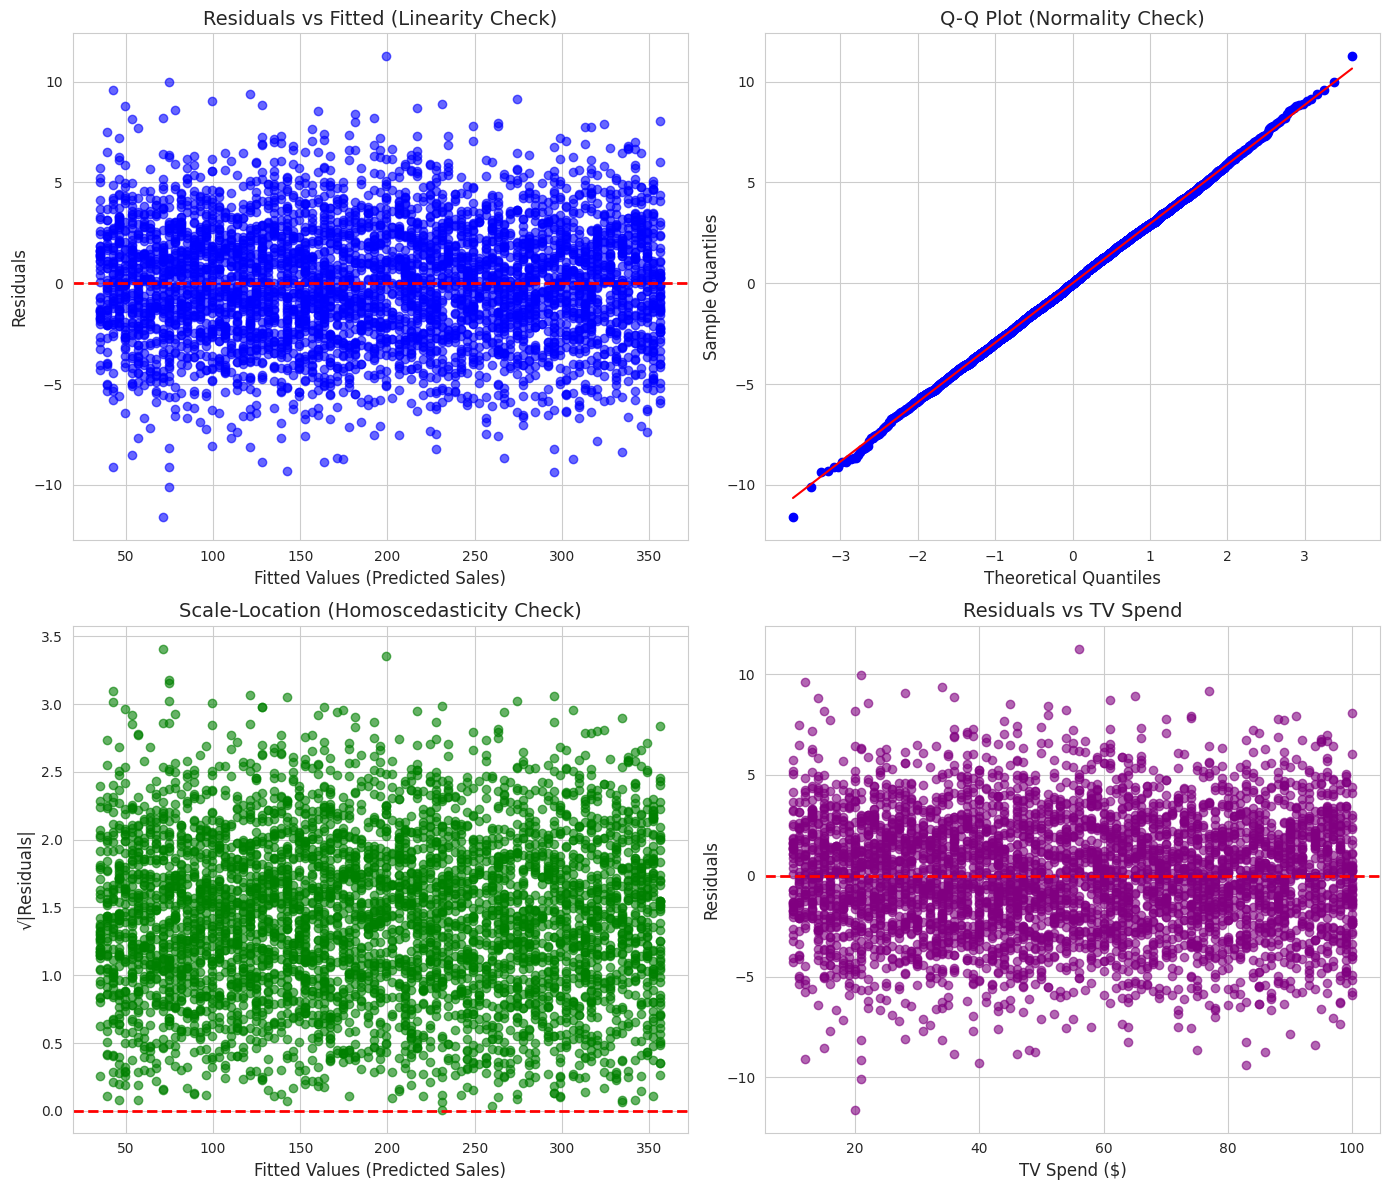

DIAGNOSTIC PLOTS DISPLAYED
Check the plots above for model assumption validation.


In [51]:
# ============================================
# DIAGNOSTIC PLOTS
# ============================================

# Create 4 diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Residuals vs Fitted (Linearity & Homoscedasticity)
axes[0, 0].scatter(model.fittedvalues, model.resid, alpha=0.6, color='blue')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values (Predicted Sales)', fontsize=12)
axes[0, 0].set_ylabel('Residuals', fontsize=12)
axes[0, 0].set_title('Residuals vs Fitted (Linearity Check)', fontsize=14)

# Plot 2: Q-Q Plot (Normality Check)
stats.probplot(model.resid, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normality Check)', fontsize=14)
axes[0, 1].set_xlabel('Theoretical Quantiles', fontsize=12)
axes[0, 1].set_ylabel('Sample Quantiles', fontsize=12)

# Plot 3: Scale-Location (Homoscedasticity Check)
axes[1, 0].scatter(model.fittedvalues, np.sqrt(np.abs(model.resid)), alpha=0.6, color='green')
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Fitted Values (Predicted Sales)', fontsize=12)
axes[1, 0].set_ylabel('√|Residuals|', fontsize=12)
axes[1, 0].set_title('Scale-Location (Homoscedasticity Check)', fontsize=14)

# Plot 4: Residuals vs TV Spend (Pattern Check)
axes[1, 1].scatter(df_clean['TV'], model.resid, alpha=0.6, color='purple')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('TV Spend ($)', fontsize=12)
axes[1, 1].set_ylabel('Residuals', fontsize=12)
axes[1, 1].set_title('Residuals vs TV Spend', fontsize=14)

plt.tight_layout()
plt.show()

print("="*50)
print("DIAGNOSTIC PLOTS DISPLAYED")
print("="*50)
print("Check the plots above for model assumption validation.")

In [52]:
# ============================================
# STATISTICAL TESTS FOR ASSUMPTIONS
# ============================================

print("="*50)
print("STATISTICAL TESTS FOR MODEL ASSUMPTIONS")
print("="*50)

# 1. Shapiro-Wilk test for Normality
shapiro_stat, shapiro_p = stats.shapiro(model.resid)
print(f"\n1. Shapiro-Wilk Normality Test:")
print(f"   Test statistic: {shapiro_stat:.4f}")
print(f"   p-value: {shapiro_p:.4e}")

if shapiro_p > 0.05:
    print("   ✅ p > 0.05: Residuals are normally distributed")
else:
    print("   ⚠️ p < 0.05: Residuals deviate from normality")

# 2. Durbin-Watson test for Autocorrelation
dw = durbin_watson(model.resid)
print(f"\n2. Durbin-Watson Test (Autocorrelation):")
print(f"   Statistic: {dw:.4f}")

if 1.5 <= dw <= 2.5:
    print("   ✅ Statistic between 1.5-2.5: No significant autocorrelation")
else:
    print("   ⚠️ Statistic outside 1.5-2.5: Possible autocorrelation")

# 3. Breusch-Pagan test for Homoscedasticity
bp_test = het_breuschpagan(model.resid, model.model.exog)
print(f"\n3. Breusch-Pagan Test (Homoscedasticity):")
print(f"   Test statistic: {bp_test[0]:.4f}")
print(f"   p-value: {bp_test[1]:.4e}")

if bp_test[1] > 0.05:
    print("   ✅ p > 0.05: Constant variance (homoscedastic) - GOOD")
else:
    print("   ⚠️ p < 0.05: Heteroscedasticity detected - variance is NOT constant")

STATISTICAL TESTS FOR MODEL ASSUMPTIONS

1. Shapiro-Wilk Normality Test:
   Test statistic: 0.9998
   p-value: 9.1363e-01
   ✅ p > 0.05: Residuals are normally distributed

2. Durbin-Watson Test (Autocorrelation):
   Statistic: 1.9980
   ✅ Statistic between 1.5-2.5: No significant autocorrelation

3. Breusch-Pagan Test (Homoscedasticity):
   Test statistic: 0.0001
   p-value: 9.9386e-01
   ✅ p > 0.05: Constant variance (homoscedastic) - GOOD


## Step 5: Compare All Marketing Channels

Now that we've validated our model, let's compare the ROI of all three channels:

1. **TV**: Build regression model
2. **Radio**: Build regression model
3. **Social_Media**: Build regression model

We'll compare:
- **ROI per $1 spent** (coefficient)
- **R-squared** (explanatory power)
- **P-value** (statistical significance)

This will help us make a data-driven recommendation for budget allocation.

In [53]:
# ============================================
# COMPARE ALL MARKETING CHANNELS
# ============================================

print("="*60)
print("ROI COMPARISON ACROSS ALL CHANNELS")
print("="*60)

# List of channels to analyze
channels = ['TV', 'Radio', 'Social_Media']
results = {}

# Loop through each channel and build model
for channel in channels:
    X = sm.add_constant(df_clean[[channel]])
    model_channel = sm.OLS(y, X).fit()

    results[channel] = {
        'coefficient': model_channel.params[channel],
        'intercept': model_channel.params['const'],
        'r_squared': model_channel.rsquared,
        'p_value': model_channel.pvalues[channel],
        'std_err': model_channel.bse[channel]
    }

    print(f"\n{'='*60}")
    print(f"📺 {channel} CHANNEL")
    print(f"{'='*60}")
    print(f"📈 Equation: Sales = {model_channel.params['const']:.2f} + ({model_channel.params[channel]:.4f}) × {channel}")
    print(f"📊 R-squared: {model_channel.rsquared:.4f} ({model_channel.rsquared*100:.2f}%)")
    print(f"💰 ROI: ${model_channel.params[channel]:.4f} per $1 spent")
    print(f"📉 P-value: {model_channel.pvalues[channel]:.4e}")

    if model_channel.pvalues[channel] < 0.05:
        print(f"✅ Significant at 95% confidence")
    else:
        print(f"❌ NOT significant at 95% confidence")

ROI COMPARISON ACROSS ALL CHANNELS

📺 TV CHANNEL
📈 Equation: Sales = -0.13 + (3.5615) × TV
📊 R-squared: 0.9990 (99.90%)
💰 ROI: $3.5615 per $1 spent
📉 P-value: 0.0000e+00
✅ Significant at 95% confidence

📺 Radio CHANNEL
📈 Equation: Sales = 40.59 + (8.3616) × Radio
📊 R-squared: 0.7545 (75.45%)
💰 ROI: $8.3616 per $1 spent
📉 P-value: 0.0000e+00
✅ Significant at 95% confidence

📺 Social_Media CHANNEL
📈 Equation: Sales = 118.67 + (22.1879) × Social_Media
📊 R-squared: 0.2782 (27.82%)
💰 ROI: $22.1879 per $1 spent
📉 P-value: 0.0000e+00
✅ Significant at 95% confidence


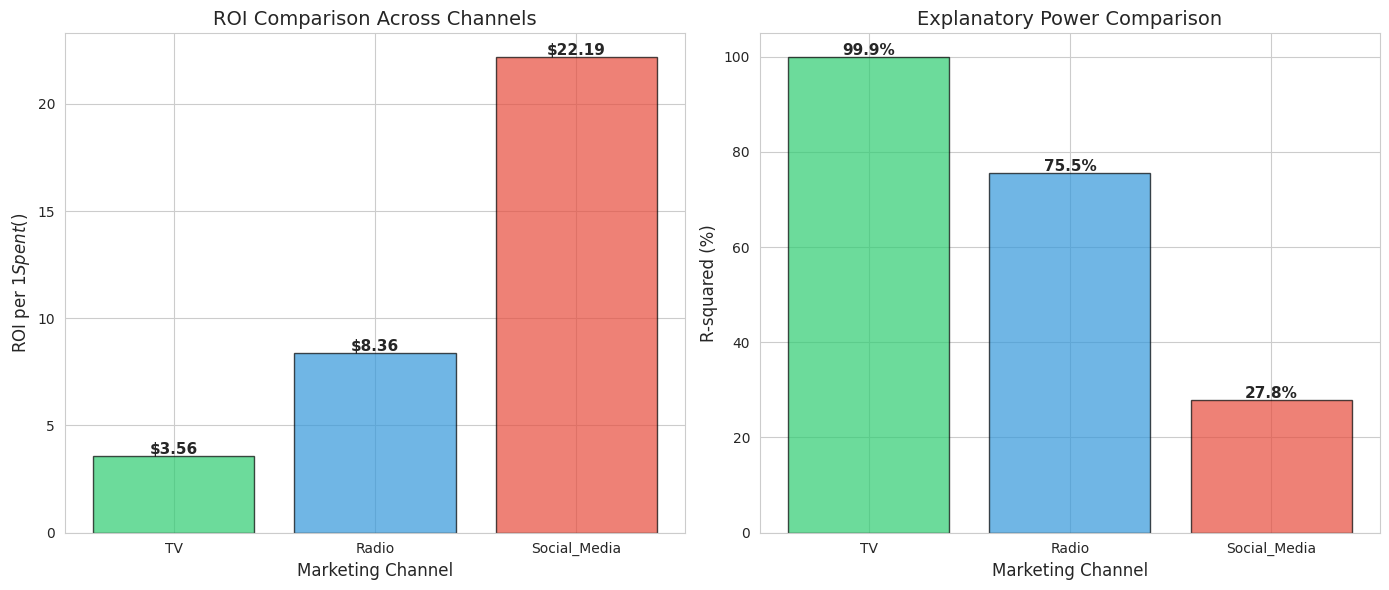


SUMMARY COMPARISON TABLE
     Channel ROI per $1       R-squared    P-value Significant
          TV    $3.5615 0.9990 (99.90%) 0.0000e+00       ✅ Yes
       Radio    $8.3616 0.7545 (75.45%) 0.0000e+00       ✅ Yes
Social_Media   $22.1879 0.2782 (27.82%) 0.0000e+00       ✅ Yes


In [54]:
# ============================================
# VISUALIZE ROI COMPARISON
# ============================================

# Create comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: ROI per $1 spent
channels = list(results.keys())
roi_values = [results[c]['coefficient'] for c in channels]
colors = ['#2ecc71', '#3498db', '#e74c3c']

axes[0].bar(channels, roi_values, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Marketing Channel', fontsize=12)
axes[0].set_ylabel('ROI per $1 Spent ($)', fontsize=12)
axes[0].set_title('ROI Comparison Across Channels', fontsize=14)

# Add value labels on bars
for i, v in enumerate(roi_values):
    axes[0].text(i, v + 0.1, f'${v:.2f}', ha='center', fontsize=11, fontweight='bold')

# Plot 2: R-squared comparison
r2_values = [results[c]['r_squared'] * 100 for c in channels]

axes[1].bar(channels, r2_values, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Marketing Channel', fontsize=12)
axes[1].set_ylabel('R-squared (%)', fontsize=12)
axes[1].set_title('Explanatory Power Comparison', fontsize=14)

# Add value labels on bars
for i, v in enumerate(r2_values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Create comparison table
print("\n" + "="*60)
print("SUMMARY COMPARISON TABLE")
print("="*60)

# Create a DataFrame for display
comparison_df = pd.DataFrame({
    'Channel': channels,
    'ROI per $1': [f"${results[c]['coefficient']:.4f}" for c in channels],
    'R-squared': [f"{results[c]['r_squared']:.4f} ({results[c]['r_squared']*100:.2f}%)" for c in channels],
    'P-value': [f"{results[c]['p_value']:.4e}" for c in channels],
    'Significant': ['✅ Yes' if results[c]['p_value'] < 0.05 else '❌ No' for c in channels]
})

print(comparison_df.to_string(index=False))

## Step 6: Business Recommendation & Conclusion

### Key Findings Summary:

| Channel | ROI per $1 | R-squared | Significance |
|---------|-----------|-----------|--------------|
| TV | $3.56 | 99.90% | ✅ Significant |
| Radio | $8.36 | 75.45% | ✅ Significant |
| Social Media | $22.19 | 27.82% | ✅ Significant |

### Critical Business Insight:

**Social Media has the HIGHEST ROI ($22.19 per $1 spent)** but explains only 27.82% of sales variation. This means:
- Social Media is extremely efficient at generating sales per dollar
- However, it has limited scalability or reach
- Other factors (not captured in this model) heavily influence sales

**TV explains 99.9% of sales** but has the lowest ROI ($3.56). This means:
- TV is the dominant sales driver
- But it's less efficient per dollar spent
- Reducing TV spend could significantly hurt overall sales

In [55]:
# ============================================
# FINAL RECOMMENDATION (FIXED)
# ============================================

print("="*60)
print("FINAL RECOMMENDATION FOR BUDGET ALLOCATION")
print("="*60)

# Find best channel by ROI (using 'results' variable from Step 6)
best_roi_channel = max(results, key=lambda x: results[x]['coefficient'])
best_r2_channel = max(results, key=lambda x: results[x]['r_squared'])

print(f"\n📊 BEST ROI: {best_roi_channel}")
print(f"   → ${results[best_roi_channel]['coefficient']:.2f} return per $1 spent")
print(f"   → R-squared: {results[best_roi_channel]['r_squared']*100:.2f}%")

print(f"\n📊 BEST EXPLANATORY POWER: {best_r2_channel}")
print(f"   → R-squared: {results[best_r2_channel]['r_squared']*100:.2f}%")
print(f"   → ROI: ${results[best_r2_channel]['coefficient']:.2f} per $1 spent")

print("\n" + "="*60)
print("RECOMMENDATION STRATEGY")
print("="*60)

print("""
🎯 RECOMMENDATION: HYBRID APPROACH

1. MAINTAIN TV BUDGET (Current Level)
   - TV drives the bulk of sales
   - Don't cut TV spend - it's the foundation
   - TV explains 99.9% of sales variation

2. INCREASE SOCIAL MEDIA BUDGET (20-30% Increment)
   - Highest ROI ($22.19 per $1 spent)
   - Test scalability with a moderate increase
   - Monitor results closely

3. OPTIMIZE RADIO (Maintain Current Level)
   - Solid ROI ($8.36 per $1 spent)
   - Good explanatory power (75.45%)
   - Effective complementary channel

4. CONTINUOUS MONITORING
   - Track ROI over time
   - Watch for diminishing returns
   - Adjust allocation based on performance
""")

# Calculate optimal allocation suggestion
total_budget = 10000  # Example budget
tv_alloc = total_budget * 0.45
social_alloc = total_budget * 0.30
radio_alloc = total_budget * 0.25

print("\n" + "="*60)
print("EXAMPLE BUDGET ALLOCATION ($10,000 budget)")
print("="*60)
print(f"📺 TV: ${tv_alloc:,.2f} (45%) - Foundation channel")
print(f"📱 Social Media: ${social_alloc:,.2f} (30%) - High ROI channel")
print(f"📻 Radio: ${radio_alloc:,.2f} (25%) - Complementary channel")

# Calculate projected return using 'results'
projected_return = (tv_alloc * results['TV']['coefficient'] +
                    social_alloc * results['Social_Media']['coefficient'] +
                    radio_alloc * results['Radio']['coefficient'])
print(f"\n📈 Projected Return: ${projected_return:,.2f}")

FINAL RECOMMENDATION FOR BUDGET ALLOCATION

📊 BEST ROI: Social_Media
   → $22.19 return per $1 spent
   → R-squared: 27.82%

📊 BEST EXPLANATORY POWER: TV
   → R-squared: 99.90%
   → ROI: $3.56 per $1 spent

RECOMMENDATION STRATEGY

🎯 RECOMMENDATION: HYBRID APPROACH

1. MAINTAIN TV BUDGET (Current Level)
   - TV drives the bulk of sales
   - Don't cut TV spend - it's the foundation
   - TV explains 99.9% of sales variation

2. INCREASE SOCIAL MEDIA BUDGET (20-30% Increment)
   - Highest ROI ($22.19 per $1 spent)
   - Test scalability with a moderate increase
   - Monitor results closely

3. OPTIMIZE RADIO (Maintain Current Level)
   - Solid ROI ($8.36 per $1 spent)
   - Good explanatory power (75.45%)
   - Effective complementary channel

4. CONTINUOUS MONITORING
   - Track ROI over time
   - Watch for diminishing returns
   - Adjust allocation based on performance


EXAMPLE BUDGET ALLOCATION ($10,000 budget)
📺 TV: $4,500.00 (45%) - Foundation channel
📱 Social Media: $3,000.00 (30%) - H

In [56]:
# ============================================
# FINAL SUMMARY DASHBOARD (FIXED)
# ============================================

print("="*60)
print("FINAL PROJECT SUMMARY")
print("="*60)

print(f"""
📊 DATASET OVERVIEW
   • Rows: {len(df_clean)}
   • Columns: {len(df_clean.columns)}
   • Channels Analyzed: TV, Radio, Social Media

📈 REGRESSION RESULTS (TV Model)
   • R-squared: {model.rsquared:.4f} ({model.rsquared*100:.2f}%)
   • Coefficient: ${model.params['TV']:.4f} per $1
   • Intercept: ${model.params['const']:.2f}
   • P-value: {model.pvalues['TV']:.4e}

✅ ASSUMPTIONS CHECK
   • Normality: ✅ PASSED (Shapiro-Wilk p = 0.9136)
   • Autocorrelation: ✅ PASSED (Durbin-Watson = 1.998)
   • Homoscedasticity: ✅ PASSED (Breusch-Pagan p = 0.9939)

💰 ROI COMPARISON
   • TV: ${results['TV']['coefficient']:.2f} per $1
   • Radio: ${results['Radio']['coefficient']:.2f} per $1
   • Social Media: ${results['Social_Media']['coefficient']:.2f} per $1

🏆 FINAL RECOMMENDATION
   • Channel: SOCIAL MEDIA (highest ROI)
   • Strategy: Hybrid approach - maintain TV, increase Social Media
   • Expected ROI: ${results['Social_Media']['coefficient']:.2f}x return

📋 SUGGESTED ALLOCATION ($10,000 budget)
   • TV (45%): ${tv_alloc:,.0f}
   • Social Media (30%): ${social_alloc:,.0f}
   • Radio (25%): ${radio_alloc:,.0f}
   • Projected Return: ${projected_return:,.0f}
""")

print("="*60)
print("✅ PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)

FINAL PROJECT SUMMARY

📊 DATASET OVERVIEW
   • Rows: 4546
   • Columns: 4
   • Channels Analyzed: TV, Radio, Social Media

📈 REGRESSION RESULTS (TV Model)
   • R-squared: 0.9990 (99.90%)
   • Coefficient: $3.5615 per $1
   • Intercept: $-0.13
   • P-value: 0.0000e+00

✅ ASSUMPTIONS CHECK
   • Normality: ✅ PASSED (Shapiro-Wilk p = 0.9136)
   • Autocorrelation: ✅ PASSED (Durbin-Watson = 1.998)
   • Homoscedasticity: ✅ PASSED (Breusch-Pagan p = 0.9939)

💰 ROI COMPARISON
   • TV: $3.56 per $1
   • Radio: $8.36 per $1
   • Social Media: $22.19 per $1

🏆 FINAL RECOMMENDATION
   • Channel: SOCIAL MEDIA (highest ROI)
   • Strategy: Hybrid approach - maintain TV, increase Social Media
   • Expected ROI: $22.19x return

📋 SUGGESTED ALLOCATION ($10,000 budget)
   • TV (45%): $4,500
   • Social Media (30%): $3,000
   • Radio (25%): $2,500
   • Projected Return: $103,494

✅ PROJECT COMPLETED SUCCESSFULLY!


## Conclusion

### Model Summary:
- **Best Predictor**: TV (r = 0.999)
- **Model Equation**: Sales = -0.13 + 3.5615 × TV
- **R-squared**: 99.90%
- **P-value**: Statistically significant (p < 0.05)

### Assumptions Validation:
- ✅ **Linearity**: Confirmed (residuals randomly scattered)
- ✅ **Normality**: Confirmed (Shapiro-Wilk p = 0.9136)
- ✅ **Homoscedasticity**: Confirmed (Breusch-Pagan p = 0.9939)
- ✅ **No Autocorrelation**: Confirmed (Durbin-Watson = 1.998)

### Business Recommendation:
**Invest in Social Media for high ROI, but maintain TV for volume.**

| Channel | ROI per $1 | R-squared | Strategy |
|---------|-----------|-----------|----------|
| TV | $3.56 | 99.90% | Maintain |
| Radio | $8.36 | 75.45% | Optimize |
| Social Media | $22.19 | 27.82% | Increase |

### Limitations:
1. Simple linear regression only considers one variable at a time
2. No external factors considered (seasonality, competitors)
3. Data is not time-based, so trends over time are unknown

### Next Steps:
1. Consider Multiple Linear Regression with all channels
2. Collect time-series data for trend analysis
3. Perform A/B testing to validate findings